In [1]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import scipy.io
import os
import re
from utils import *
import psana

In [2]:
###############################################
runNumbers = [15,16,17,18,19,20,21,22,23,24,25,26,27,28]  # enter the run numbers to be loaded
#folder = '/sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/' # insert here the directory path where .h5 files are stored
#folder = '/sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/'
folder = '/sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/'
###############################################
# (1) keys_to_combine: some keys loaded for each shot & stored per shot 
# (2) keys_to_sum: some keys loaded per each run and added 
# (3) keys_to_check : check if some keys exits and have same values in all runs and load these keys 
keys_to_combine = [#'CXI-DG2-BMMON-WF/ROI_area',
                    'jungfrau4M/azav_mask0_azav', # Unfiltered
                   'jungfrau4M/azav_mask1_azav', # Filtered
                   'dg2ipmReproc/sum',
                   'dg2ipmReproc/peaks',
                   'dg2ipmReproc/xpos',
                   'dg2ipmReproc/ypos',
                   'gas_detector/f_11_ENRC',
                   'ebeam/photon_energy',
                   'evr/code_183',
                   'evr/code_137',
                   'evr/code_141',
                   'lightStatus/xray',
                  'jungfrau4M/Full_thres_sum',
                  'feeBld/hproj',
                  'lightStatus/laser',
                   'ipm_dg2/sum',
                    'ipm_hfx_dg2/sum',
                   'unixTime',
                   'epicsUser/gasCell_pressure',
                  ]

keys_to_sum = ['Sums/jungfrau4M_calib']
#               'Sums/jungfrau4M_calib_thresADU1']

keys_to_check = ['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q',
                 'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq',
                 'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q', # This are only needed once
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi', # This are only needed once
                'UserDataCfg/jungfrau4M/x',
                'UserDataCfg/jungfrau4M/y',
                'UserDataCfg/jungfrau4M/z',
                'UserDataCfg/jungfrau4M/cmask']
# Load the data in
data = combineRuns(runNumbers, folder, keys_to_combine, keys_to_sum, keys_to_check, verbose=False)  # this is the function to load the data with defined keys

# Filtered Data
azavFiltered = np.squeeze(data['jungfrau4M/azav_mask0_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbinFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin'] # q bin-size
qFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q'] # q bins 
qbinsFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins'] # q bins
userMaskFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask'].astype(bool) # User mask for this region
qbinSizeFiltered = np.bincount(data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq'])
# Unfiltered Data
azav = np.squeeze(data['jungfrau4M/azav_mask1_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbin = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin'] # q bin-size
q = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q'] # q bins 
qbins = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins'] # q bins
userMask = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask'].astype(bool) # User mask for this region
qbinSize = np.bincount(data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq'])
# Other Data
matrix_q = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q'].reshape(8,512,1024) # Q values J4M shaped
matrix_phi = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi'].reshape(8,512,1024) # phi valyes J4M shaped
xrayOn = data['evr/code_137'].astype(bool)  # xray on events
xrayOn2 = data['lightStatus/xray'].astype(bool)  # xray on events
laserOn = data['lightStatus/laser'].astype(bool)  # xray on events
jungfrau_sum = data['Sums/jungfrau4M_calib']  # Total Jungfrau detector counts summed in a run
#jungfrau_sum = data['Sums/jungfrau4M_calib_thresADU1']   # Total Jungfrau detector counts with Thresholds added, summed in a run 
x = data['UserDataCfg/jungfrau4M/x'] # coordinates of Jungfrau detector x,y,z
y = data['UserDataCfg/jungfrau4M/y']
z = data['UserDataCfg/jungfrau4M/z'] 

cmask = data['UserDataCfg/jungfrau4M/cmask'].astype(bool) # Mask for detector created 
run_indicator = data['run_indicator'] # run indicator for each shot
#pressure = data['epicsAll/gasCell_pressure']  # pressure in gas cell
xray_energy = data['gas_detector/f_11_ENRC']   # xray energy from gas detector (not calibrated to actual values)
xray_eV = data['ebeam/photon_energy']    # x-ray energy energy in eV|
numPhotons = data['jungfrau4M/Full_thres_sum']
spec = data['feeBld/hproj'] # Shot to shot spectrometer
#dg2traces = data['CXI-DG2-BMMON-WF/ROI_area'] # Downsampling by a factor of 8, makes the refitting much better in the long run
gasPressure = data['epicsUser/gasCell_pressure']
eventTime = data['unixTime']
ipm = data['dg2ipmReproc/sum']
ipmpeaks = data['dg2ipmReproc/peaks']
xpos = data['dg2ipmReproc/xpos']
ypos = data['dg2ipmReproc/ypos']
# hfxSum = data['ipm_hfx_dg2/sum']
#dg2tracesFull = data['CXI-DG2-BMMON-WF/ROI_rebin_data']
del data

# For some reason we need to offet the data by one. Will this be a problem in later experiments?
spec = spec[0:-2];
azavFiltered = azavFiltered[1:-1];
azav = azav[1:-1];
xrayOn = xrayOn[1:-1];
xrayOn2 = xrayOn2[1:-1];
laserOn = laserOn[1:-1];
ipm = ipm[1:-1];
ipmpeaks = ipmpeaks[1:-1];
xpos = xpos[1:-1];
ypos = ypos[1:-1];

eventTime = eventTime[1:-1];
gasPressure = gasPressure[1:-1];

Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0015.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0016.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0017.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0018.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0019.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0020.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0021.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0022.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0023.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0024.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch

Text(0.5, 0, 'Shot Number')

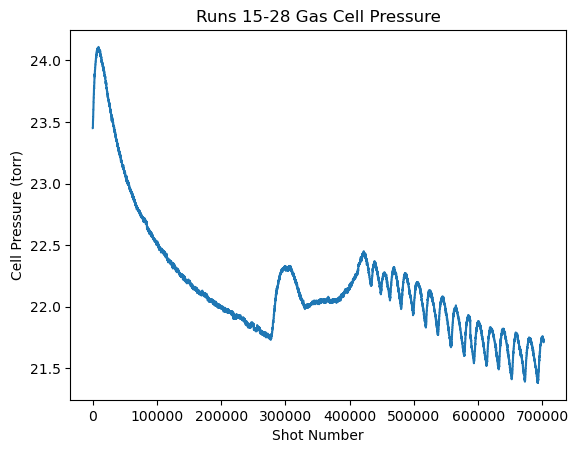

In [3]:
plt.plot(gasPressure);
plt.title('Runs 15-28 Gas Cell Pressure')
plt.ylabel('Cell Pressure (torr)')
plt.xlabel('Shot Number')

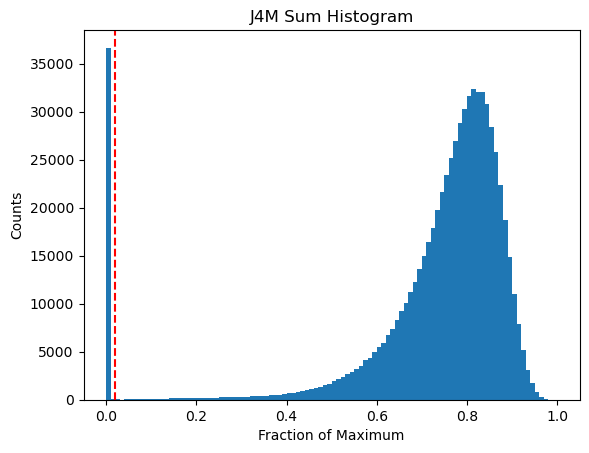

In [4]:
##########
integration_cutoff_hb = 0.2
integration_cutoff_lb = 0.05
scattering_cutoff = 0.02
##########
scattered_xrays = np.sum(azav,axis=-1)
#scattered_xraysFiltered = np.sum(azavFiltered*qbinSizeFiltered,axis=-1)

plt.hist(scattered_xrays/scattered_xrays.max(),bins=100);
plt.axvline(scattering_cutoff,color='r',linestyle='--')
plt.title('J4M Sum Histogram')
plt.xlabel('Fraction of Maximum')
plt.ylabel('Counts')
plt.show()
# Doing the actual filtering
goodIdx = (xrayOn2) & (scattered_xrays/scattered_xrays.max()>scattering_cutoff) & (~np.isnan(scattered_xrays))
specGood = spec[goodIdx]
#dg2Good = dg2traces[goodIdx]
J4MSum = scattered_xrays[goodIdx]
gasPGood = gasPressure[goodIdx]
ipmGood = ipm[goodIdx]

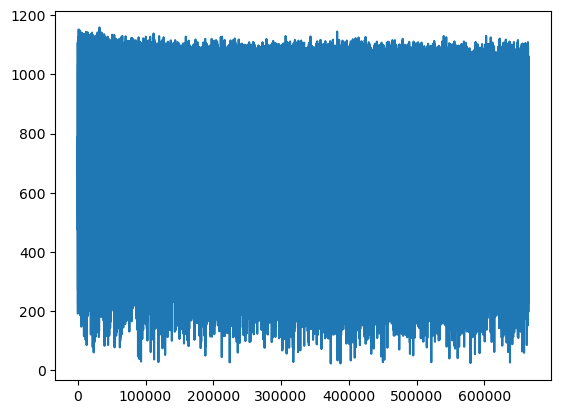

In [5]:
plt.plot(J4MSum)

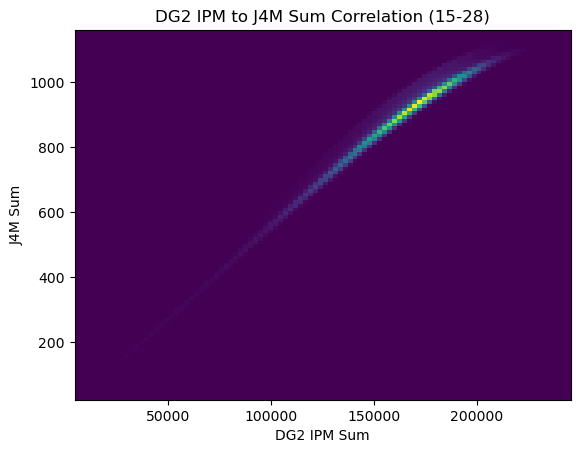

In [6]:
plt.title('DG2 IPM to J4M Sum Correlation (15-28)')
plt.ylabel('J4M Sum')
plt.xlabel('DG2 IPM Sum')
hist2dLinFit(ipmGood,J4MSum,100);

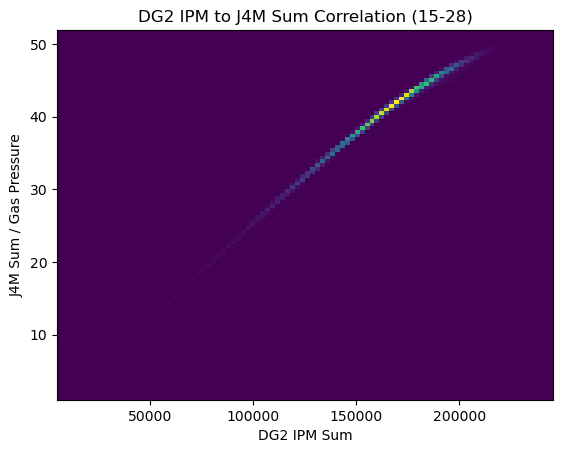

In [7]:
plt.title('DG2 IPM to J4M Sum Correlation (15-28)')
plt.ylabel('J4M Sum / Gas Pressure')
plt.xlabel('DG2 IPM Sum')
hist2dLinFit(ipmGood,(J4MSum/gasPGood),100);

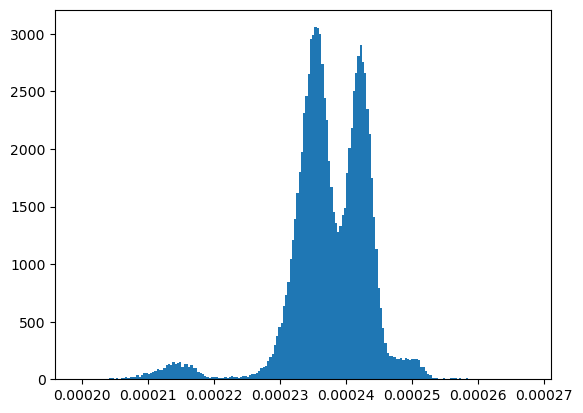

In [31]:
plt.hist((J4MSum/gasPGood)/ipmGood,200);

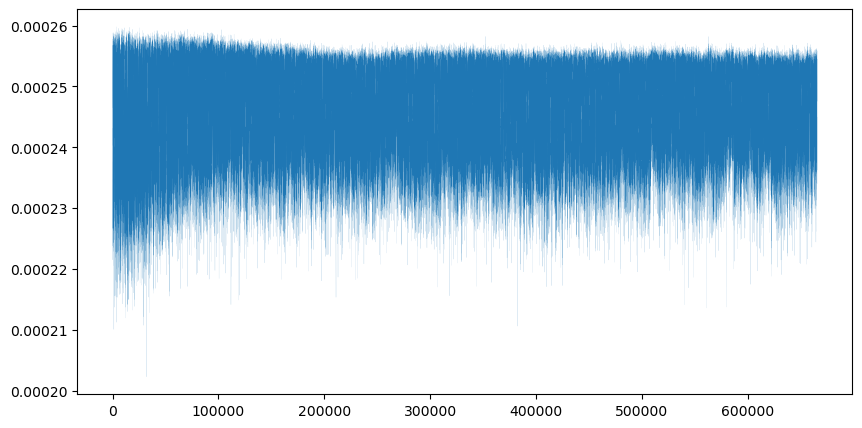

In [9]:
plt.figure(figsize=[10,5])
plt.plot((J4MSum/gasPGood)/ipmGood,linewidth=0.05)

In [292]:
import psana
import numpy as np
##########################
runNumber=298
experiment='cxil1037623'
nTotEvents = 3609
##########################
dsname = 'exp=%s:run=%d:smd' % (experiment , runNumber) 
ds = psana.DataSource(dsname)
# LCLS1 uses 3 numbers to define an event.  In LCLS2 this is one number.
evtTime = []
fiducials   = []

# get some times of events (these could come from a saved "small data" file, for example)
for nevent,evt in enumerate(ds.events()):
    evtid = evt.get(psana.EventId)
    tsec, tnsec = evtid.time()
    fid = evtid.fiducials()
    evtTime.append(tsec+tnsec/1e9)
    # evtId = evt.get(EventId)
    # seconds.append(evtId.time()[0])
    # nanoseconds.append(evtId.time()[1])
    # fiducials.append(evtId.fiducials())
    #if nevent==2: break


In [293]:
evtT = np.array(evtTime)

In [100]:
from datetime import datetime, timedelta, timezone
from epicsArch import *
# Initialize the EpicsArchive object
archive = EpicsArchive()
pv = 'CXI:MKS670:READINGGET' # PV for the gas cell pressure
start_time = eventTime[0] # UNIX timestamp format
end_time = eventTime[-1] # UNIX timestamp format
[times,pressure] = archive.get_points(PV=pv, start=start_time, end=end_time,unit="seconds",raw=True,two_lists=True);

276


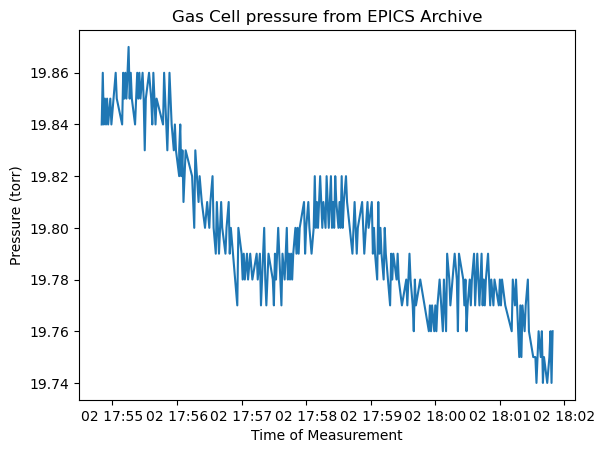

In [101]:
timestamps = np.array(times)
datetimes = [datetime.datetime.utcfromtimestamp(ts) for ts in timestamps]
plt.plot(datetimes, pressure);
plt.title('Gas Cell pressure from EPICS Archive')
plt.ylabel('Pressure (torr)')
plt.xlabel('Time of Measurement')
print(len(pressure))

In [102]:
from scipy.interpolate import interp1d
# Interpolation function
interp_func = interp1d(times, pressure, kind='previous', fill_value='extrapolate')

# Interpolated pressure values
newP = interp_func(eventTime)

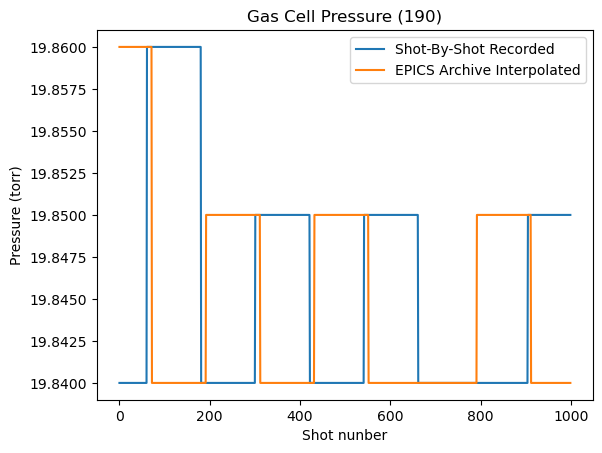

In [103]:
plt.figure()
#plt.plot(gasPressure[83:][-500:]);
plt.plot(gasPressure[0:1000],label='Shot-By-Shot Recorded')
plt.plot(newP[0:1000],label='EPICS Archive Interpolated')
plt.title('Gas Cell Pressure (190)')
plt.xlabel('Shot nunber')
plt.ylabel('Pressure (torr)')
plt.legend()
#plt.plot(newP[:-83][-500:]);

In [104]:
dsq = np.sum((gasPressure-newP)**2)

In [105]:
dsq = np.zeros(200)
for i in range(-100,100):
    dsq[i+100] = np.sum((gasPressure[200:-100]-newP[200+i:-100+i])**2)

Text(0.1, 0.8, 'Best Offset: -24')

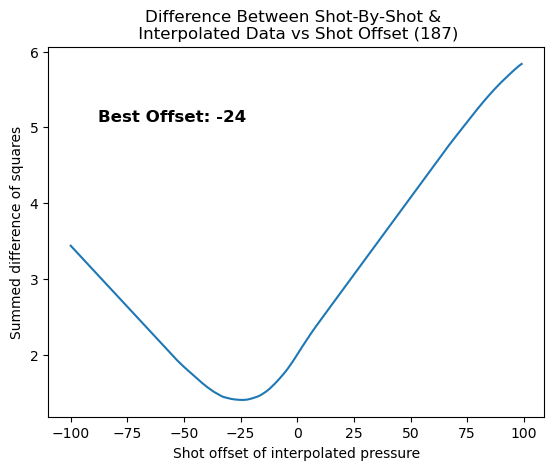

In [106]:
plt.plot(np.arange(-100,100,1),dsq)
plt.title(f'Difference Between Shot-By-Shot & \n Interpolated Data vs Shot Offset ({runNumbers[0]})')
plt.xlabel('Shot offset of interpolated pressure')
plt.ylabel('Summed difference of squares')
plt.text(0.1, 0.8, f'Best Offset: {np.argmin(dsq)-100}',
             fontsize=12, fontweight='bold', transform=plt.gca().transAxes, ha='left', color='Black')

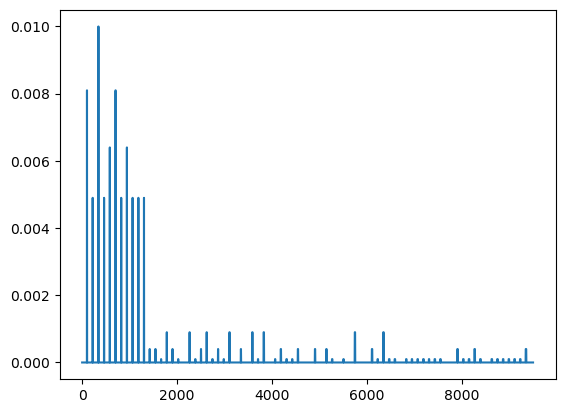

In [431]:
i=-80
plt.plot((gasPressure[500:10000]-newP[500+i:10000+i])**2)

In [5]:
import numpy as np
foo = np.arange(100,200,1);
foo[np.where(foo>150)[-1]]

array([151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163,
       164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176,
       177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189,
       190, 191, 192, 193, 194, 195, 196, 197, 198, 199])

In [10]:
foo = np.append(foo,10)

In [11]:
foo

array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151,
       152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164,
       165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177,
       178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190,
       191, 192, 193, 194, 195, 196, 197, 198, 199,  10,  10])